In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mesa_reader import MesaData
from astropy import units as u
from astropy.constants import G
import scipy.constants as const
import os
import pickle
import sys
import pandas as pd
from matplotlib.lines import Line2D


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    "axes.titlesize": 15,      
    "axes.labelsize": 13,      
    "xtick.labelsize": 11,     
    "ytick.labelsize": 11,     
    "legend.fontsize": 11,     
})


In [2]:
def load_csv_fortran(filename):
    with open(filename, 'r') as f:
        header = f.readline().strip()
        col_names = header.split(',')
        lines = [line.replace('D+', 'E+').replace('D-', 'E-') for line in f.readlines()]
    data = np.genfromtxt(lines, delimiter=',')
    return col_names, data

# Data MESA vs CEPAM vs Completo

I load the different planet files, based on temperature, mass, radius, metallicity and core mass.

In [18]:
t = 1000
m = 1.0
r = 2.0
z = 0.017

mcore = 10
#core_mass = "Mcore=0.01Me_homogeneous"
core_mass = "Mcore=10Me"


In [20]:
# Files
# MESA
mesa_file_history = f"/data/MESA/inert_core_planets/{core_mass}/inert_core_models_{t}K/evolve_models_{t}K/inert_core_evolved/planet_evolve_{m}_Mj_{r}_Rj_zbar={z}_inert_core_s=11.0.history"
mesa_data_history = np.loadtxt(mesa_file_history, skiprows=6)

mesa_file_profile = f"/data/MESA/inert_core_planets/{core_mass}/inert_core_models_{t}K/evolve_models_{t}K/inert_core_evolved/planet_evolve_{m}_Mj_{r}_Rj_zbar={z}_inert_core_s=11.0.profile"
mesa_data_profile = np.loadtxt(mesa_file_profile, skiprows=6)

# CEPAM
cepam_file_ev = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_{r}Rj_{z}z_0.01s/mev_ev.csv" 
col_names, cepam_data_ev = load_csv_fortran(cepam_file_ev)

cepam_file_evol = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_{r}Rj_{z}z_0.01s/mev_evol.csv" 
col_names, cepam_data_evol = load_csv_fortran(cepam_file_evol)

# Completo 
completo_file_ev = f"/data/Completo21/Teq{t}K/{m}Mj_Mcore_{mcore}/evolution_000.outputdat"
completo_data_ev = np.loadtxt(completo_file_ev)

completo_file_int = f"/data/Completo21/Teq{t}K/{m}Mj_Mcore_{mcore}/internalst_000.outputdat"
completo_data_int = np.loadtxt(completo_file_ev)




# Radius vs Age

I compare the radius of planets with the same characteristics, made with three different simulation codes.

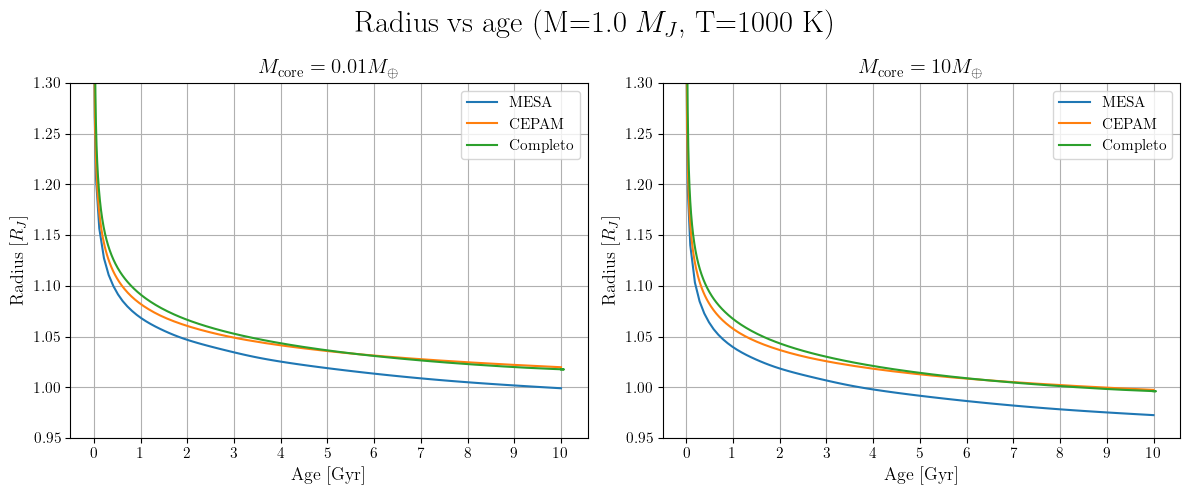

In [107]:
core_masses = ["Mcore=0.01Me_homogeneous", "Mcore=10Me"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
fig.suptitle(f"Radius vs age (M={m} $M_J$, T={t} K)", fontsize=22)
axes = [ax1, ax2]

m = 1.0
t = 1000

for ax, core_mass in zip(axes, core_masses):
    if core_mass == "Mcore=0.01Me_homogeneous":
        Mcore = 0.01
    if core_mass == "Mcore=10Me":
        Mcore = 10
        
    mesa_file_history = f"/data/MESA/inert_core_planets/{core_mass}/inert_core_models_{t}K/evolve_models_{t}K/inert_core_evolved/planet_evolve_{m}_Mj_{r}_Rj_zbar={z}_inert_core_s=11.0.history"
    mesa_data_history = np.loadtxt(mesa_file_history, skiprows=6)
    cepam_file_ev = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_{r}Rj_{z}z_0.01s/mev_ev.csv" 
    col_names, cepam_data_ev = load_csv_fortran(cepam_file_ev)
    completo_file_ev = f"/data/Completo21/Teq{t}K/{m}Mj_Mcore_{Mcore}/evolution_000.outputdat"
    completo_data_ev = np.loadtxt(completo_file_ev)

    # MESA
    age_m = mesa_data_history[:, 2] # in yr
    age_m = age_m/(10**9)
    radius_m = (mesa_data_history[:, 8] * u.R_sun).to(u.R_jup)
    
    # CEPAM
    age_c = cepam_data_ev[:,0] # in Myr
    age_c = age_c * 10**6 # in yr
    age_c = age_c/(10**9) # in Gyr 
    radius_c = (cepam_data_ev[:,2] * u.cm).to(u.R_jup) # in cm
    
    # Completo
    age_cp = completo_data_ev[:, 1] # in years
    age_cp = age_cp / (10**9) # in Gyr
    radius_cp = completo_data_ev[:, 6] * u.R_jup # total radius
    
    # Plotting
    ax.plot(age_m, radius_m, label="MESA", color = "tab:blue")
    ax.plot(age_c, radius_c, label="CEPAM", color = "tab:orange")
    ax.plot(age_cp, radius_cp, label="Completo", color = "tab:green")

    ax.set_xlabel("Age [Gyr]")
    ax.set_ylabel("Radius [$R_J$]")
    ax.set_ylim(0.95, 1.3)
    ax.set_xticks(range(0, 11, 1))
    ax.set_title(f"$M_{{\\mathrm{{core}}}} = {Mcore} M_{{\\oplus}}$")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

    

# Density and pressure profile plots

In the plot below I summarize the internal structure of simulated planets. I show the density vs normalized radius (q), density vs temperature, pressure vs normalized radius and pressure vs temperature. Every subplot shows planets made with the three different simulation codes and three different equilibrium temperatures of the planets. This is for planets with a specific mass, radius, metallicity and core mass.

Missing MESA file: /Users/emmavolkers/Documents/Sterrenkunde/First_Master_Research_Project/MESA/inert_core_planets/Mcore=10Me/inert_core_models_300K/evolve_models_300K/inert_core_evolved/planet_evolve_1.0_Mj_2.0_Rj_zbar=0.017_inert_core_s=11.0.profile


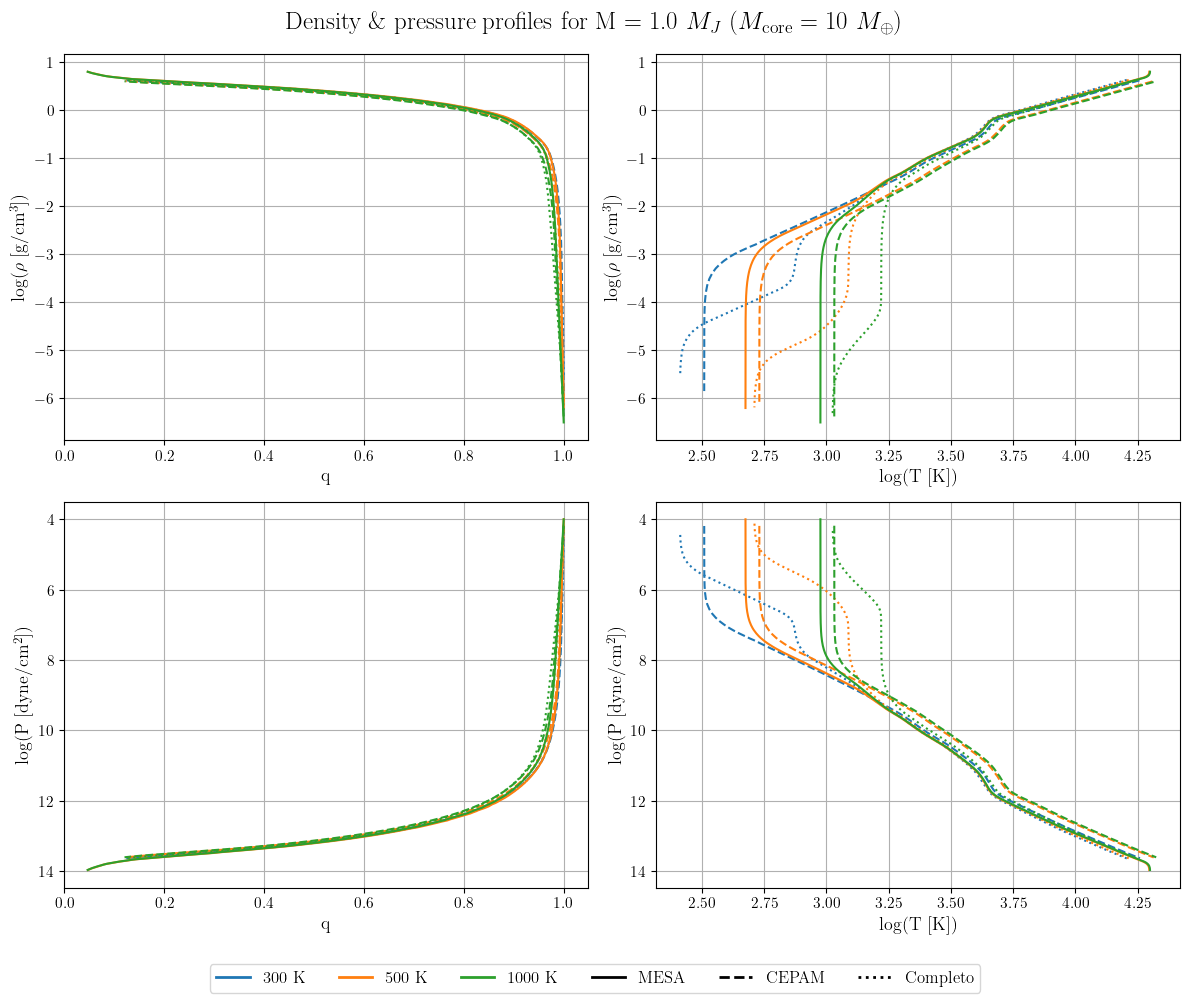

In [210]:
m = 1.0
r = 2.0
z = 0.017  
#core_mass = "Mcore=0.01Me_homogeneous" 
core_mass = "Mcore=10Me"
mcore = 10

temperatures = [300, 500, 1000]
colors = {300: "tab:blue", 500: "tab:orange", 1000: "tab:green"}
linestyles = {"MESA": "-", "CEPAM": "--", "Completo": ":"}

data = {core_mass: {}}

for t in temperatures:
    data[core_mass][t] = {}

########## CEPAM
    cepam_file_evol = f"/data/CEPAM/projects_planets/{core_mass}/projects_{t}K/my_planets_{t}K/{m}Mj/{m}Mj_{r}Rj_{z}z_0.01s/mev_evol.csv" 
    if os.path.exists(cepam_file_evol):
        col_names, cepam_data_evol = load_csv_fortran(cepam_file_evol)

        logP_c   = cepam_data_evol[1:200, 3]
        logRho_c = cepam_data_evol[1:200, 5]
        radius_c = cepam_data_evol[1:200, 2]
        q_c      = radius_c / np.max(radius_c)
        logT_c   = cepam_data_evol[1:200, 4]
        T_c      = 10**logT_c

        data[core_mass][t]["CEPAM"] = (logT_c, logRho_c, logP_c, q_c)
    else:
        print(f"Missing CEPAM file: {cepam_file_evol}")
        data[core_mass][t]["CEPAM"] = None

############## MESA
    mesa_file_profile = f"/data/MESA/inert_core_planets/{core_mass}/inert_core_models_{t}K/evolve_models_{t}K/inert_core_evolved/planet_evolve_{m}_Mj_{r}_Rj_zbar={z}_inert_core_s=11.0.profile"
    if os.path.exists(mesa_file_profile):
        mesa_data_profile = np.loadtxt(mesa_file_profile, skiprows=6)

        q_m      = mesa_data_profile[:, 11]
        radius_m = mesa_data_profile[:, 13]
        q_m      = radius_m / np.max(radius_m)
        T_m      = mesa_data_profile[:, 14]
        logT_m   = np.log10(T_m)
        logP_m   = mesa_data_profile[:, 5]
        logRho_m = mesa_data_profile[:, 4]

        data[core_mass][t]["MESA"] = (logT_m, logRho_m, logP_m, q_m)
    else:
        print(f"Missing MESA file: {mesa_file_profile}")
        data[core_mass][t]["MESA"] = None

############# Completo
    completo_file_int = f"/data/Completo21/Teq{t}K/{m}Mj_Mcore_{mcore}/internalstructure_000.outputdat"
    if os.path.exists(completo_file_int):
        completo_data_int = np.loadtxt(completo_file_int)

        radius_cp = completo_data_int[:, 1]
        q_cp      = radius_cp / np.max(radius_cp)
        T_cp      = completo_data_int[:, 6]
        logT_cp   = np.log10(T_cp)
        pressure_cp = completo_data_int[:, 5] * 10**6
        logP_cp   = np.log10(pressure_cp)
        rho_cp    = completo_data_int[:, 7]
        logRho_cp = np.log10(rho_cp)

        data[core_mass][t]["Completo"] = (logT_cp, logRho_cp, logP_cp, q_cp)
    else:
        print(f"Missing Completo file: {completo_file_int}")
        data[core_mass][t]["Completo"] = None

if core_mass == "Mcore=0.01Me_homogeneous":
    Mcore = 0.01
if core_mass == "Mcore=10Me":
    Mcore = 10

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    rf"Density \& pressure profiles for M = {m} $M_J$ ($M_{{\mathrm{{core}}}}$ = {Mcore} $M_{{\oplus}}$)",
    fontsize=18, y=0.99
)

# Different subplots
panel_map = {
    (0, 0): ("rho", "q"),   # rho vs q
    (0, 1): ("rho", "T"),   # rho vs T
    (1, 0): ("P",   "q"),   # P vs q
    (1, 1): ("P",   "T"),   # P vs T
}

for (i, j), (y_key, x_key) in panel_map.items():
    ax = axes[i, j]

    if y_key == "rho":
        y_label = r"log($\rho$ [g/cm$^{3}$])"
    else:
        y_label = r"log(P [dyne/cm$^{2}$])"

    x_label = "q" if x_key == "q" else "log(T [K])"

    for t in temperatures:
        for code in ["MESA", "CEPAM", "Completo"]:
            entry = data[core_mass][t][code]
            if entry is None:
                continue

            T, logRho, logP, q = entry

            # Select x-data
            x = q if x_key == "q" else T

            # Select y-data
            y = logRho if y_key == "rho" else logP

            ax.plot(x, y, color=colors[t], linestyle=linestyles[code])

    if y_key == "P":
        ax.invert_yaxis()

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True)

# Legend
legend_elements = [
    Line2D([0], [0], color="tab:blue",   lw=2, label="300 K"),
    Line2D([0], [0], color="tab:orange", lw=2, label="500 K"),
    Line2D([0], [0], color="tab:green",  lw=2, label="1000 K"),
    Line2D([0], [0], color="black", lw=2, linestyle="-",  label="MESA"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="CEPAM"),
    Line2D([0], [0], color="black", lw=2, linestyle=":",  label="Completo"),
]

fig.legend(handles=legend_elements, loc="lower center", ncol=6, fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
